## KNN Baseline Classification – Objective

The goal of this notebook is to evaluate a K-Nearest Neighbors (KNN) classifier as a simple distance-based baseline for identifying MDD from EEG-derived features. KNN serves as a bridge between unsupervised structure and supervised classification by testing whether MDD and healthy samples naturally form separable neighborhoods in feature space. This allows us to assess how well the geometric structure revealed through clustering and dimensionality reduction translates into actual predictive performance, and to compare it against linear models, SVMs, and deep learning approaches.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from pathlib import Path

from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def find_project_root():
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Project root (.git) not found")


PROJECT_ROOT = find_project_root()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "nm000114"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_features"
RESULTS_DIR = PROJECT_ROOT / "results"
SEGMENTED_DATA_DIR = PROJECT_ROOT / "data" / "segmented_data"

In [3]:
def infer_label_from_subject(subject_id):
    subject_upper = subject_id.upper()
    if "HS" in subject_upper:
        return 0
    elif "MDD" in subject_upper:
        return 1
    else:
        raise ValueError(subject_id)


def parse_condition_from_filename(filepath):
    name = filepath.name
    if "task-eyesClosed" in name:
        return "eyesClosed"
    elif "task-eyesOpen" in name:
        return "eyesOpen"
    elif "task-P300" in name:
        return "P300"
    else:
        raise ValueError(name)


edf_files = sorted(RAW_DATA_DIR.glob("sub*/eeg/*.edf"))

rows = []
for filepath in edf_files:
    subject_id = filepath.parts[-3]
    rows.append({
        "patient_id": subject_id,
        "recording_id": filepath.stem,
        "label": infer_label_from_subject(subject_id),
        "condition": parse_condition_from_filename(filepath),
        "filepath": str(filepath),
    })

metadata_df = pd.DataFrame(rows)


COMMON_CHANNELS = [
    'EEG Fp1-LE','EEG F3-LE','EEG C3-LE','EEG P3-LE','EEG O1-LE',
    'EEG F7-LE','EEG T3-LE','EEG T5-LE','EEG Fz-LE','EEG Fp2-LE',
    'EEG F4-LE','EEG C4-LE','EEG P4-LE','EEG O2-LE','EEG F8-LE',
    'EEG T4-LE','EEG T6-LE','EEG Cz-LE','EEG Pz-LE','EEG A2-A1'
]


def extract_band_power(epoch_data, sfreq):
    bands = {
        "delta": (1, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30)
    }

    feats = []

    for ch in epoch_data:
        psd, freqs = mne.time_frequency.psd_array_welch(
            ch,
            sfreq=sfreq,
            fmin=1,
            fmax=30,
            n_fft=min(len(ch), 256),
            n_per_seg=min(len(ch), 256),
            verbose=False
        )

        total = psd.sum()

        band_feats = [
            psd[(freqs >= fmin) & (freqs <= fmax)].mean() / total
            if total > 0 else 0
            for (fmin, fmax) in bands.values()
        ]

        feats.append(band_feats)

    return np.nan_to_num(np.array(feats).flatten())


def build_dataset(metadata_df, window_sec=5.0):

    X, y, groups = [], [], []

    for _, row in metadata_df.iterrows():

        raw = mne.io.read_raw_edf(row["filepath"], preload=True, verbose=False)
        raw.pick(COMMON_CHANNELS)

        epochs = mne.make_fixed_length_epochs(
            raw,
            duration=window_sec,
            overlap=0.0,
            preload=True,
            verbose=False
        )

        data = epochs.get_data()
        sfreq = epochs.info["sfreq"]

        for i in range(len(data)):
            X.append(extract_band_power(data[i], sfreq))
            y.append(row["label"])
            groups.append(row["patient_id"])

    return np.vstack(X), np.array(y), np.array(groups)


X_seg, y_seg, groups_seg = build_dataset(metadata_df, window_sec=5.0)

LR: 0.8098051932733684
SVM: 0.8138054804906767
KNN: 0.7974910296730464


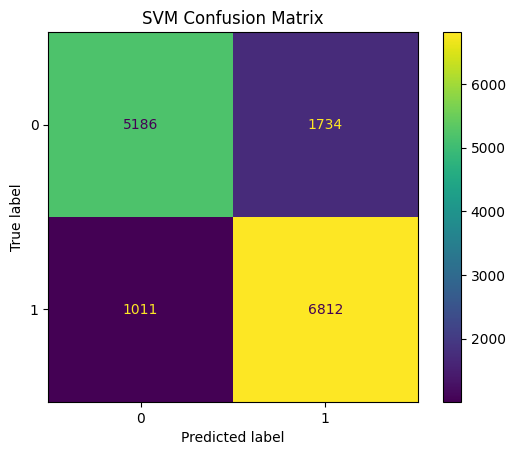

In [4]:

gkf = GroupKFold(n_splits=5)

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True))
])

pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=5))
])


def evaluate(model):
    res = cross_validate(
        model,
        X_seg,
        y_seg,
        groups=groups_seg,
        cv=gkf.split(X_seg, y_seg, groups_seg),
        scoring=["accuracy", "f1", "roc_auc"]
    )
    return res


lr_res = evaluate(pipeline_lr)
svm_res = evaluate(pipeline_svm)
knn_res = evaluate(pipeline_knn)


print("LR:", np.mean(lr_res["test_accuracy"]))
print("SVM:", np.mean(svm_res["test_accuracy"]))
print("KNN:", np.mean(knn_res["test_accuracy"]))


y_pred = cross_val_predict(
    pipeline_svm,
    X_seg,
    y_seg,
    groups=groups_seg,
    cv=gkf.split(X_seg, y_seg, groups_seg)
)

cm = confusion_matrix(y_seg, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("SVM Confusion Matrix")
plt.show()